# Using ChatGPT-4 API for Image Text Extraction and Question Answering

This notebook demonstrates how to use the ChatGPT-4 API to extract information from an image, such as the bounding boxes and the text within those boxes. We will also show how to ask questions about the content of the image, for example, information contained in a document.

## Installation

First, we need to install the required libraries. You can install them using pip.

In [ ]:
# Install the required libraries
!pip install openai

# Get your API key!

1. Visit this [link](https://platform.openai.com/settings/profile?tab=api-keys) to get your API key.
2. Press "+ Create new secret key" to create a new API key.
3. Fill in the name of the key and (optional) configure the permissions as shown in the image below. Then press "Create" to create the key.
   
<img src="../assets/tutorials/create_new_secret_key_dialog.png" alt="Create secret key" width="500" />

1. Copy the API key. WARNING: This is the only time you will be able to see the key. Make sure to save it in a secure location.

<img src="../assets/tutorials/save_your_key_dialog.png" alt="Save your key" width="500" />

## Initialize OpenAI Client

You need to set up your OpenAI API key to use the API. Replace `your_api_key` with your actual OpenAI API key.

In [4]:
from openai import OpenAI

OPENAI_API_KEY = "sk-your-api-key"

# Initialize the OpenAI client
client = OpenAI(api_key=OPENAI_API_KEY)

## Preview your document

We will load the image from a specified path and display it.

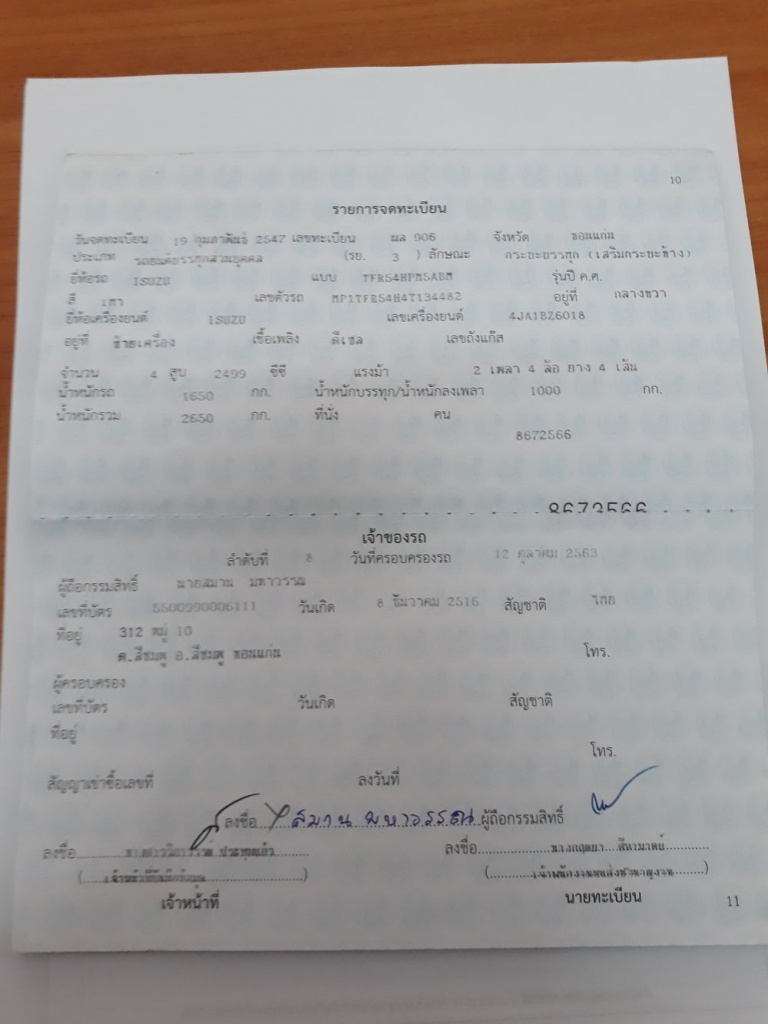

In [1]:
from PIL import Image

# Load the image from a path
image_path = "path/to/your/image.jpg"
image = Image.open(image_path)

display(image)

## Encode image to url link with base64
To send the image to the ChatGPT-4 API, we need to encode the image to a base64 string and then convert it to a URL link.

Base64 image: ...
Image link: 

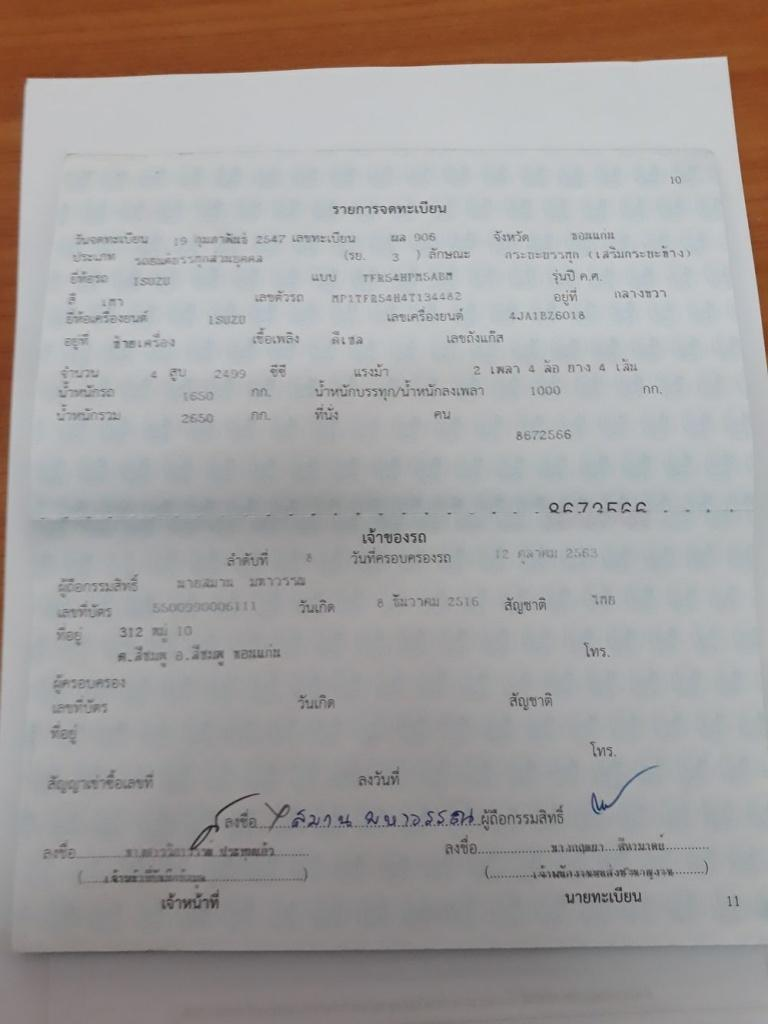

In [2]:
import base64
import io


def encode_image(image: Image.Image) -> str:
    """Encode an image into base64 format."""
    buffered = io.BytesIO()
    image.save(buffered, format="JPEG")
    return base64.b64encode(buffered.getvalue()).decode("utf-8")


def create_link(base64_image: str) -> str:
    """Create a link from a base64 image."""
    return f"data:image/jpeg;base64,{base64_image}"


# Encode the image
encoded_image = encode_image(image)
print("Base64 image:", encoded_image)
image_link = create_link(encoded_image)
print("Image link:", image_link)

## Asking Questions about the Image

We will send a question to the ChatGPT-4 API along with the image to get an answer about its content.

In [5]:
def extract_information(image_path: str, question: str) -> str:
    """Extract information from the image and return the answer."""
    # Load the image
    image = Image.open(image_path)
    # Encode the image
    encoded_image = encode_image(image)
    image_link = create_link(encoded_image)

    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {
                "role": "system",
                "content": "You are a helpful assistant designed to extract information from the input document and user question. Please always answer the question based on the information extracted from the document and in a concise manner.",
            },
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": question,
                    },
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": image_link,
                        },
                    },
                ],
            },
        ],
    )

    answer = response.choices[0].message.content
    return answer


question = "น้ำหนักรถรวมเท่าไหร่"
answer = extract_information(image_path, question)
print("Question:", question)
print("Answer:", answer)

Question: น้ำหนักรถรวมเท่าไหร่
Answer: จากเอกสารที่ให้มา น้ำหนักรถรวมเท่ากับ 2650 กิโลกรัม (กก.).


# Extract Information from the document

## Create question prompt

In [7]:
extract_question = """You are provided with a scanned or photographed image of a Thai vehicle registration book (สมุดทะเบียนรถ). Your task is to extract the following information from the image.The extracted value is typically located on the right side of the key in the document.
Extract these details:

1. วันจดทะเบียน (date_of_registration)
2. เลขทะเบียน (registration_no)
3. จังหวัด (car_province)
4. ประเภท (vehicle_use)
5. รย. (type)
6. ลักษณะ (body_style)
7. ยี่ห้อรถ (manufacturer)
8. แบบ (model)
9. รุ่นปี คศ (year)
10. สี (color)
11. เลขตัวรถ (chassis_number)
12. อยู่ที่ (chassis_location)
13. ยี่ห้อเครื่องยนต์ (engine_manufacturer)
14. เลขเครื่องยนต์ (engine_number)
15. อยู่ที่ (engine_location)
16. เชื้อเพลิง (fuel_type)
17. เลขถังแก๊ส (fuel_tank_number)
18. จำนวน (cylinders)
19. ซีซี (cubic_capacity)
20. แรงม้า (horse_power)
21. จำนวนเพลาและล้อ (axles_wheels_no)
22. น้ำหนักรถ (unladen_weight)
23. น้ำหนักบรรทุก/น้ำหนักเพลา (load_capacity)
24. น้ำหนักรวม (gross_weight)
25. ที่นั่ง (seats)

Instructions:

Carefully examine the image and locate each piece of information.
If a particular field is not visible or not present in the image, use the value "N/A" for that field.
Ensure all text extracted from the image is in its original language (Thai or English) as it appears in the document.
Return the extracted information in a JSON format, using the English key names provided in parentheses.
Only return the JSON output, without any additional explanation or text.

Example of expected output format:
{
  "date_of_registration": "1 ม.ค. 2566",
  "registration_no": "กข 1234",
  "car_province": "กรุงเทพมหานคร",
  ...
  "seats": "4"
}
"""

In [20]:
from IPython.display import Markdown

answer = extract_information(image_path, extract_question)
print("Answer:")
print(answer)

Answer:


{
  "date_of_registration": "19 เมษายน 2547",
  "registration_no": "ชฉ 006",
  "car_province": "ขอนแก่น",
  "vehicle_use": "รถบรรทุก (ส่วนบุคคล)",
  "type": "ISUZU",
  "body_style": "กระบะถลาว2",
  "manufacturer": "ISUZU",
  "model": "TFB54HPM7ASBM",
  "year": "ม.ค.",
  "color": "เงิน",
  "chassis_number": "MP1TFR54H4T134462",
  "chassis_location": "เหนือเพลาหลัง",
  "engine_manufacturer": "ISUZU",
  "engine_number": "4JA1BZ6018",
  "engine_location": "อยู่เหนือแซสซี",
  "fuel_type": "ดีเซล",
  "fuel_tank_number": "N/A",
  "cylinders": "4",
  "cubic_capacity": "2499",
  "horse_power": "N/A",
  "axles_wheels_no": "2 เพลา 4 ล้อ ล้อหน้า 4 ล้อ",
  "unladen_weight": "1650 กก.",
  "load_capacity": "1000 กก.",
  "gross_weight": "2650 กก.",
  "seats": "คู่"
}

Because the output from the ChatGPT-4 API can be error sometimes, we will create a clean prompt to ask the model to reformat the output.

In [17]:
def clean_json(json_answer: str) -> str:
    """Extract information from the image and return the answer."""
    # Clean prompt
    clean_prompt = """
You are a JSON formatting assistant. Your task is to take a potentially malformed or incomplete JSON string and return a properly formatted, valid JSON object. Follow these steps:

1. Analyze the input text for JSON-like structure.
2. Identify and correct common JSON formatting errors such as:
   - Missing closing braces or brackets
   - Trailing commas
   - Unquoted keys
   - Missing values
3. If a value is missing or incomplete, use "N/A" as the value.
4. Ensure all keys and string values are properly quoted with double quotes.
5. Remove any extraneous text before or after the JSON object.
6. Format the JSON with proper indentation for readability.

Input: {}

Instructions:
- Return only the corrected JSON object, without any additional explanation or text.
- Ensure the output is a complete, valid JSON object that can be parsed by Python's json.loads() function.
- Preserve the original data as much as possible, only making changes necessary for valid JSON formatting.

Example of expected output format:
{{
  "key1": "value1",
  "key2": "value2",
  "key3": "N/A"
}}
"""
    # Make the API call
    response = client.chat.completions.create(
        model="gpt-4o",  # or another suitable model
        messages=[
            {"role": "system", "content": "You are a JSON formatting assistant."},
            {"role": "user", "content": clean_prompt},
        ],
    )

    # Extract the cleaned JSON from the response
    cleaned_json_str = response.choices[0].message.content
    return cleaned_json_str

In [28]:
# Try to parse the JSON, if it fails, clean it
import json


def parse_json(answer: str) -> dict:
    """Parse a JSON string and return a dictionary."""
    try:
        # Remove ```json from the start and end of the string
        # and try to parse the JSON
        answer = answer.replace("```json", "").replace("```", "")
        answer = json.loads(answer)

    except json.JSONDecodeError:
        answer = clean_json(answer)
    return answer


# Parse the JSON
answer = parse_json(answer)
print("Parsed JSON:")
print(answer)

Parsed JSON:
{'date_of_registration': '3 มีนาคม 2560', 'registration_no': '1กธ 7670', 'car_province': 'นครศรีธรรมราช', 'vehicle_use': 'รถจักรยานยนต์', 'type': '(รย. 12) ล้อสามล้อ', 'body_style': 'รถจักรยานยนต์', 'manufacturer': 'HONDA', 'model': 'SCOOPY I', 'year': '2017', 'color': 'ขาว', 'chassis_number': 'MTHJF7270FS017530', 'chassis_location': 'คานหลังกร่าง', 'engine_manufacturer': 'N/A', 'engine_number': 'JF727E-0017530', 'engine_location': 'เสื้อสูบซ้ายล่าง', 'fuel_type': 'เบนซิน', 'fuel_tank_number': 'N/A', 'cylinders': 'N/A', 'cubic_capacity': '108', 'horse_power': 'N/A', 'axles_wheels_no': '1 เพลา 2 ล้อ หน้า 1 ล้อ', 'unladen_weight': 'N/A', 'load_capacity': 'N/A', 'gross_weight': 'N/A', 'seats': '2'}


## Let's run on all images!

In [31]:
from pathlib import Path

import pandas as pd
from tqdm.auto import tqdm

dataset_dir = Path("datasets/Srisawad Deep Learning")
paths = list(dataset_dir.glob("*.jpg"))
extracted_information = []

for path in tqdm(paths, desc="Processing images"):
    answer = extract_information(image_path=path, question=extract_question)
    answer = parse_json(answer)
    # Add the path to the extracted information, so we can track it later
    filename = str(Path(path).name)
    answer["filename"] = filename
    # Save the extracted information
    extracted_information.append(answer)

# Convert the extracted information to a DataFrame
dataframe = pd.DataFrame(extracted_information)
dataframe.to_excel(dataset_dir / "predictions.xlsx", index=False)
# Preview the DataFrame
display(dataframe)

,date_of_registration,registration_no,car_province,vehicle_use,type,body_style,manufacturer,model,year,color,...,fuel_tank_number,cylinders,cubic_capacity,horse_power,axles_wheels_no,unladen_weight,load_capacity,gross_weight,seats,filename
0,9 มีนาคม 2560,1กข 7670,นครศรีธรรมราช,รถจักรยานยนต์,12,ลักษณะ,HONDA,SCOOPY I,2017,ขาว,...,N/A,1 สูบ,108 ซีซี,N/A,1 เพลา 2 ล้อ 2 เส้น,N/A,N/A,N/A,2 คน,mc_รายการจดทะเบียน_3.jpg
1,4 กรกฎาคม 2555,นแ 2449,พระนครศรีอยุธยา,รถยนตส่วนบุคคล,รย.3,กระบะบรรทุก (แค็บกระบะท้าย),TOYOTA,TGN16R-TRMDKT,ค.ศ.2012,ขาว,...,"C2435088, C2435188, C241317",4,2694,160,2 เพลา 4 ล้อ ยาง 4 เส้น,1600,1050,2650,2,ca_รายการจดทะเบียน_2.jpg
2,31 พฤษภาคม 2553,บร 8375,กรุงเทพมหานคร,รถยนต์นั่งส่วนบุคคลเกิน 7 คน,2,นั่ง,TOYOTA,HIACE,2010,ขาว,...,N/A,4,2494,109,2 เพลา 4 ล้อหลัง 4 ล้อ,2100,N/A,N/A,14,ca_รายการจดทะเบียน_3.jpg


# Evaluation

In [45]:
## evaluate CER & accuracy (%) for each column
import pandas as pd
from torchmetrics.text import CharErrorRate

annotated_df = pd.read_excel("datasets/labels.xlsx")
predicted_df = pd.read_excel("datasets/predictions.xlsx")

columns_of_interest = [
    "date_of_registration",
    "registration_no",
    "car_province",
    "vehicle_use",
    "type",
    "body_style",
    "manufacturer",
    "model",
    "year",
    "color",
    "chassis_number",
    "chassis_location",
    "engine_manufacturer",
    "engine_number",
    "engine_location",
    "fuel_type",
    "fuel_tank_number",
    "cylinders",
    "cubic_capacity",
    "horse_power",
    "axles_wheels_no",
    "unladen_weight",
    "load_capacity",
    "gross_weight",
    "seats",
]

results = []

for column in columns_of_interest:
    cer = CharErrorRate()
    cer_list = []
    accuracy_list = []

    for index, row in annotated_df.iterrows():
        annotated_value = row[column]
        predicted_value = predicted_df.loc[index, column]

        # Convert values to strings if they are not already strings
        if not isinstance(annotated_value, str):
            annotated_value = str(annotated_value)
        if not isinstance(predicted_value, str):
            predicted_value = str(predicted_value)

        # If both values are 'N/A', skip CER calculation and append 0 CER and 1 for accuracy
        if annotated_value == "N/A" and predicted_value == "N/A":
            cer_list.append(0.0)
            accuracy_list.append(1)
        else:
            # Compute CER for non-'N/A' values
            cer_value = cer(predicted_value, annotated_value).item()
            cer_list.append(cer_value)

            # Check if the prediction is accurate (exact match)
            if annotated_value == predicted_value:
                accuracy_list.append(1)
            else:
                accuracy_list.append(0)

    # Calculate the average CER and accuracy for the column
    average_cer = sum(cer_list) / len(cer_list)
    accuracy = sum(accuracy_list) / len(accuracy_list)

    results.append(
        {"column": column, "average_cer": average_cer, "accuracy": accuracy * 100}
    )

report = pd.DataFrame(results)
report.to_excel(dataset_dir / "evaluation.xlsx", index=False)